# Off-line Granule Assay NIR Paired Comparison

## Purpose

This notebook supports a paired comparative study for Off-line Granule Assay NIR. It is intended for cases where the same granule sample presentation can be measured by both the old and changed NIR procedures before reference analysis.

## Method-specific context

The paired design assumes the same granule sample is measured by the old and new NIR methods. Reference analysis should be performed after the NIR measurements where feasible, preserving traceability to the paired NIR observations.

For granule assay, vial/sample presentation can affect spectra. Refill, repacking, and presentation variability should be considered during protocol design and should be documented in the study dataset.

For final CP/GMP use, paired precision should use a CP-approved method and input source, such as known old-method variance or duplicate independent measurements. The observed SD-ratio option used in this synthetic example is supportive/exploratory for heterogeneous paired samples unless justified.

## Input configuration

In [33]:
from pathlib import Path

import pandas as pd
from IPython.display import Markdown, display

from nir_cp.method_config import get_method_config
from nir_cp.notebook_export import export_notebook_pdf
from nir_cp.paired_comparison import paired_comparison_decision
from nir_cp.plots import plot_bland_altman, plot_difference_vs_reference, plot_old_vs_new
from nir_cp.report_equations import display_equation, display_equation_set
from nir_cp.report_tables import display_report_dataframe
from nir_cp.reporting_text import paired_decision_summary_text
from nir_cp.simulation import simulate_paired_comparison_success

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "examples").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

METHOD_KEY = "granule_assay_nir"
method_config = get_method_config(METHOD_KEY, PROJECT_ROOT / "config" / "method_defaults.yaml")

DATA_PATH = PROJECT_ROOT / "examples" / "granule_assay_paired_example.csv"
METHOD_NAME = method_config["method_display_name"]

# User-overridable placeholders. Replace with CP-approved method-specific criteria before GMP use.
D_EQUIVALENCE_MARGIN = method_config["d_equivalence_margin"]
K_PRECISION_RATIO = method_config["k_precision_ratio"]
ALPHA_ACCURACY = method_config["alpha_accuracy"]
ALPHA_PRECISION = method_config["alpha_precision"]
PRECISION_METHOD = "observed_sd_ratio_exploratory"
OLD_VARIANCE = None
ALLOW_EXPLORATORY_PRECISION_AS_PRIMARY = True
N_SIM = 500
RANDOM_SEED = 12345
EXPORT_REPORT = True

display_report_dataframe(pd.DataFrame([method_config]), transpose_if_one_row=True);

parameter,value
method_display_name,Off-line Granule Assay NIR
d_equivalence_margin,1.000
k_precision_ratio,2.000
alpha_accuracy,0.050
alpha_precision,0.050
recommended_min_n,18
notes,Example placeholder. Replace with CP-approved method-specific criterion before GMP use.


## Load data

In [34]:
df = pd.read_csv(DATA_PATH)
display_report_dataframe(df, max_rows=10);
display_report_dataframe(df[["batch_id", "granule_lot", "refill_replicate", "vial_id"]], max_rows=10);

sample_id,batch_id,granule_lot,vial_id,old_nir,new_nir,reference,refill_replicate,analyst,instrument_old,instrument_new,date
G-SYN-001,G-B001,G-L001,V001,99.600,99.800,99.700,1,GA01,NIR-OLD-G01,NIR-NEW-G01,2026-02-02
G-SYN-002,G-B001,G-L001,V002,100.200,100.300,100.100,1,GA01,NIR-OLD-G01,NIR-NEW-G01,2026-02-02
G-SYN-003,G-B001,G-L001,V003,98.900,99.100,99.000,2,GA02,NIR-OLD-G01,NIR-NEW-G01,2026-02-02
G-SYN-004,G-B001,G-L001,V004,101.000,100.900,101.100,2,GA02,NIR-OLD-G01,NIR-NEW-G01,2026-02-02
G-SYN-005,G-B002,G-L002,V005,99.400,99.500,99.300,1,GA01,NIR-OLD-G01,NIR-NEW-G01,2026-02-03
G-SYN-006,G-B002,G-L002,V006,100.800,100.700,100.900,1,GA01,NIR-OLD-G01,NIR-NEW-G01,2026-02-03
G-SYN-007,G-B002,G-L002,V007,98.700,98.900,98.800,2,GA02,NIR-OLD-G01,NIR-NEW-G01,2026-02-03
G-SYN-008,G-B002,G-L002,V008,101.300,101.400,101.200,2,GA02,NIR-OLD-G01,NIR-NEW-G01,2026-02-03
G-SYN-009,G-B003,G-L003,V009,100.000,100.100,100.200,1,GA01,NIR-OLD-G01,NIR-NEW-G01,2026-02-04
G-SYN-010,G-B003,G-L003,V010,99.100,99.200,99.000,1,GA01,NIR-OLD-G01,NIR-NEW-G01,2026-02-04


batch_id,granule_lot,refill_replicate,vial_id
G-B001,G-L001,1,V001
G-B001,G-L001,1,V002
G-B001,G-L001,2,V003
G-B001,G-L001,2,V004
G-B002,G-L002,1,V005
G-B002,G-L002,1,V006
G-B002,G-L002,2,V007
G-B002,G-L002,2,V008
G-B003,G-L003,1,V009
G-B003,G-L003,1,V010


# Statistical theory and decision rules

<!-- SVG equation metadata for tests: $$$$ \mu_D \bar{D} \sigma_N -->

## Study design

The same physical sample/tablet is measured with the current/old and changed/new NIR procedure. The paired difference is defined as:

In [ ]:
_ = display_equation(r"D_i = Y_{N,i} - Y_{O,i}")

Pairing removes between-sample variation from the accuracy comparison. This notebook calls tested functions under `src/nir_cp/` and does not implement independent pass/fail logic.

## Accuracy equivalence

The paired accuracy hypotheses are:

In [ ]:
_ = display_equation_set([
    r"H_0: |\mu_D| \ge d",
    r"H_A: |\mu_D| < d",
])

The sample mean and variance of the paired differences are:

In [ ]:
_ = display_equation_set([
    r"\bar{D} = \frac{1}{n}\sum_{i=1}^{n}D_i",
    r"s_D^2 = \frac{\sum_{i=1}^{n}(D_i-\bar{D})^2}{n-1}",
])

The confidence interval used for paired accuracy is:

In [ ]:
_ = display_equation(r"\bar{D} \pm t_{1-\alpha,n-1}\frac{s_D}{\sqrt{n}}")

For `alpha = 0.05`, this is a two-sided 90% confidence interval used for TOST equivalence. The accuracy criterion is met if the full confidence interval is contained within:

In [ ]:
_ = display_equation(r"[-d, +d]")

## Precision noninferiority

The precision hypotheses are:

In [ ]:
_ = display_equation_set([
    r"H_0: \frac{\sigma_N}{\sigma_O} \ge k",
    r"H_A: \frac{\sigma_N}{\sigma_O} < k",
])

Precision assessment depends on the study design and available variance information. For heterogeneous paired samples, the preferred primary precision method should be either paired design with known/historical old-method variance, or duplicate independent measurements for old and new procedures. The observed raw SD ratio across heterogeneous paired samples is supportive/exploratory unless explicitly justified in the CP.

For the known old-variance option, the upper bound is:

In [ ]:
_ = display_equation(r"U = \sqrt{\frac{(n-1)s_D^2}{\sigma_O^2\chi^2_{\alpha,n-1}} - 1}")

with decision rule:

In [ ]:
_ = display_equation(r"U < k")

For the duplicate-measurement option, the duplicate scaled differences are:

In [ ]:
_ = display_equation_set([
    r"d_{O,i} = \frac{Y_{O,i,1}-Y_{O,i,2}}{\sqrt{2}}",
    r"d_{N,i} = \frac{Y_{N,i,1}-Y_{N,i,2}}{\sqrt{2}}",
])

and an F-based one-sided upper confidence bound is used for `sigma_N / sigma_O`.

> Precision method note: the observed SD-ratio calculation shown in this example is supportive/exploratory for heterogeneous paired samples unless specifically justified in the CP. Final CP/GMP use should apply the CP-approved primary precision method.

## Values used in this notebook

The table below is generated from the notebook variables and input data. Calculations and final pass/fail decisions are performed by tested functions under `src/nir_cp/`.

In [35]:
values_used = {
    "method name": METHOD_NAME,
    "precision_method": PRECISION_METHOD,
    "n": len(df),
    "d": D_EQUIVALENCE_MARGIN,
    "k": K_PRECISION_RATIO,
    "alpha_accuracy": ALPHA_ACCURACY,
    "alpha_precision": ALPHA_PRECISION,
    "random seed": RANDOM_SEED,
    "n_sim": N_SIM,
}
if OLD_VARIANCE is not None:
    values_used["old_variance"] = OLD_VARIANCE

display_report_dataframe(pd.DataFrame([values_used]), transpose_if_one_row=True);

parameter,value
method name,Off-line Granule Assay NIR
precision_method,observed_sd_ratio_exploratory
n,24
d,1.000
k,2.000
alpha_accuracy,0.050
alpha_precision,0.050
random seed,12345
n_sim,500


## Data checks

In [36]:
required_columns = [
    "sample_id",
    "batch_id",
    "granule_lot",
    "vial_id",
    "old_nir",
    "new_nir",
    "reference",
    "refill_replicate",
    "analyst",
    "instrument_old",
    "instrument_new",
    "date",
]
missing_columns = sorted(set(required_columns) - set(df.columns))
if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")
if df[required_columns].isna().any().any():
    raise ValueError("Input data contain missing values in required columns.")
if df["sample_id"].duplicated().any():
    raise ValueError("sample_id values must be unique.")
for column in ["old_nir", "new_nir", "reference"]:
    df[column] = pd.to_numeric(df[column], errors="raise")

df["difference_new_minus_old"] = df["new_nir"] - df["old_nir"]
df["average_old_new"] = (df["old_nir"] + df["new_nir"]) / 2

display_report_dataframe(
    pd.DataFrame(
        [{
            "n_pairs": len(df),
            "recommended_min_n": method_config["recommended_min_n"],
            "mean_old_nir": df["old_nir"].mean(),
            "mean_new_nir": df["new_nir"].mean(),
            "mean_difference_new_minus_old": df["difference_new_minus_old"].mean(),
            "sd_old_nir": df["old_nir"].std(ddof=1),
            "sd_new_nir": df["new_nir"].std(ddof=1),
        }]
    ),
    transpose_if_one_row=True,
);

parameter,value
n_pairs,24.000
recommended_min_n,18.000
mean_old_nir,99.992
mean_new_nir,100.058
mean_difference_new_minus_old,0.067
sd_old_nir,0.892
sd_new_nir,0.832


## Paired comparison decision

In [37]:
decision = paired_comparison_decision(
    old_values=df["old_nir"],
    new_values=df["new_nir"],
    d=D_EQUIVALENCE_MARGIN,
    k=K_PRECISION_RATIO,
    alpha_accuracy=ALPHA_ACCURACY,
    alpha_precision=ALPHA_PRECISION,
    precision_method=PRECISION_METHOD,
    old_variance=OLD_VARIANCE,
    allow_exploratory_precision_as_primary=ALLOW_EXPLORATORY_PRECISION_AS_PRIMARY,
)

display(Markdown(paired_decision_summary_text(decision, method_name=METHOD_NAME)))
display_report_dataframe(pd.DataFrame([decision["accuracy"]]), transpose_if_one_row=True);
display_report_dataframe(pd.DataFrame([decision["precision"]]), transpose_if_one_row=True);
display_report_dataframe(pd.DataFrame([{"overall_pass": decision["overall_pass"], "decision_text": decision["decision_text"]}]), transpose_if_one_row=True);

Off-line Granule Assay NIR met the predefined criteria for paired accuracy equivalence and precision noninferiority. The paired mean difference (new - old) was 0.067, with a 90.0% confidence interval from 0.030 to 0.103; the predefined equivalence margin was +/-1.000. The upper confidence bound for the precision ratio (sigma_new / sigma_old) was 1.323, compared with the predefined limit k=2.000.

parameter,value
pass,True
d,1.000
alpha,0.050
ci_confidence,0.900
mean_difference,0.067
lower,0.030
upper,0.103
n,24


parameter,value
sd_old,0.892
sd_new,0.832
ratio_observed,0.932
upper_bound,1.323
alpha,0.050
n_old,24
n_new,24
df_old,23
df_new,23
method,observed_sd_ratio_exploratory


parameter,value
overall_pass,True
decision_text,The changed NIR method met the predefined paired accuracy equivalence and exploratory observed-SD precision criteria. This precision method is supportive/exploratory and is not the preferred USP <1010> paired precision method for heterogeneous samples unless justified.


## Supporting plots

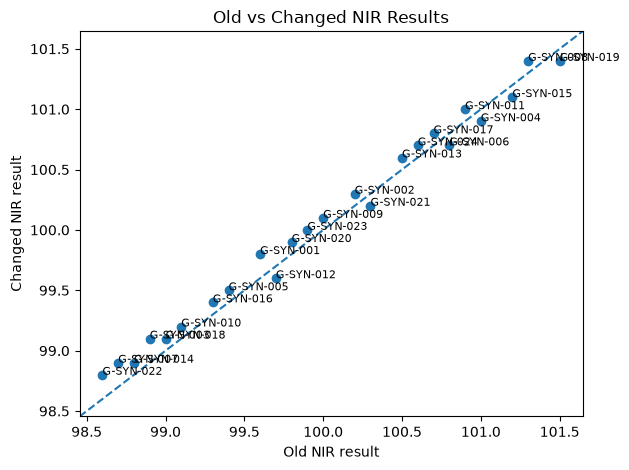

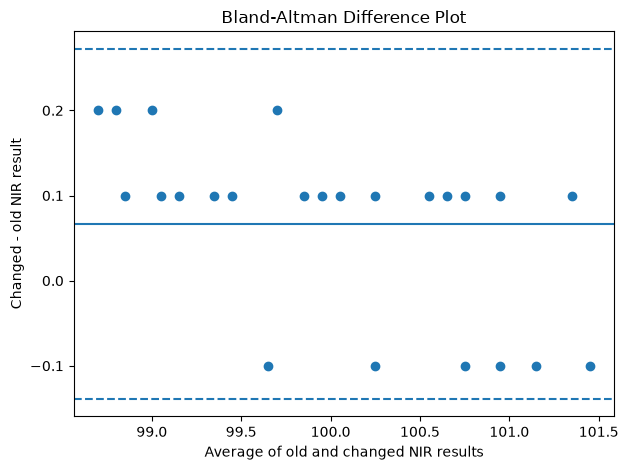

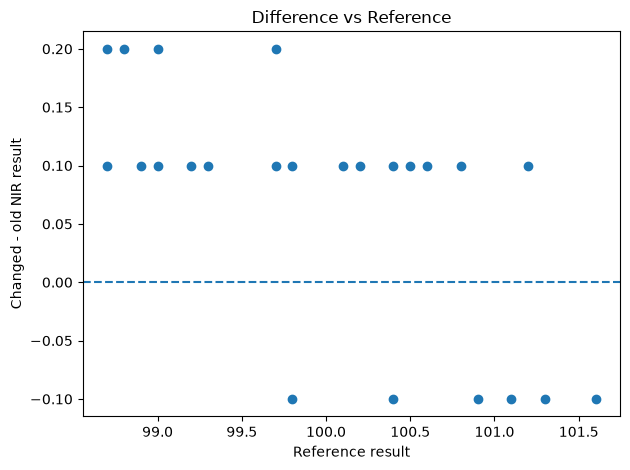

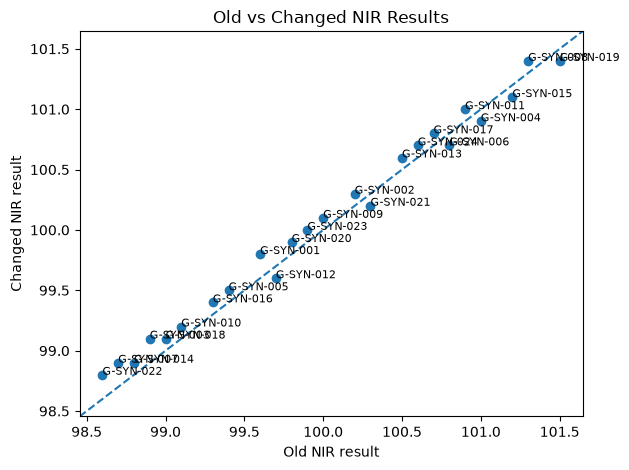

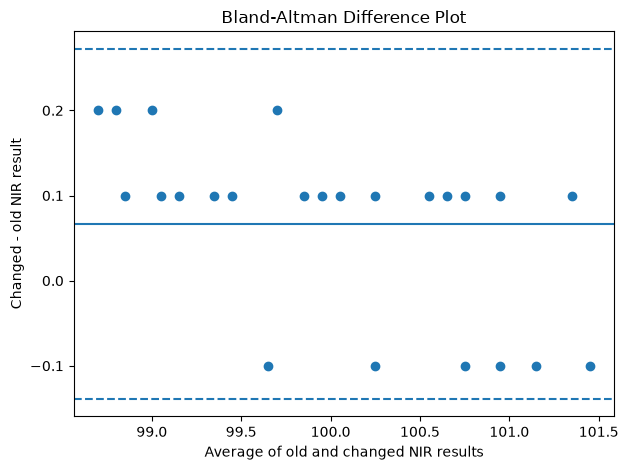

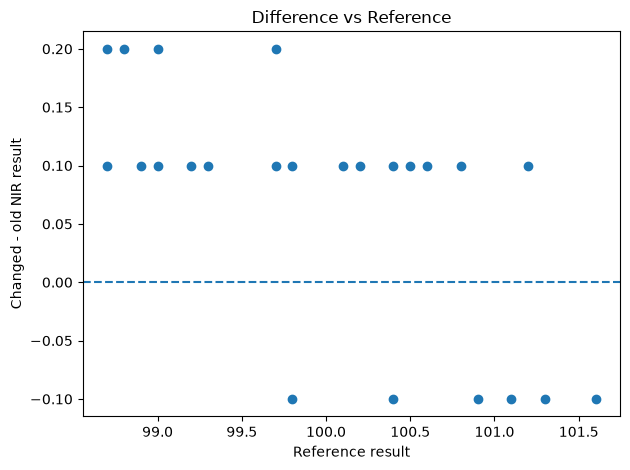

In [38]:
display(plot_old_vs_new(df, sample_id_col="sample_id"))
display(plot_bland_altman(df))
display(plot_difference_vs_reference(df))

## Probability-of-success simulation

In [39]:
simulation_result = simulate_paired_comparison_success(
    n=len(df),
    true_bias=float(df["difference_new_minus_old"].mean()),
    old_sd=float(df["old_nir"].std(ddof=1)),
    new_sd=float(df["new_nir"].std(ddof=1)),
    d=D_EQUIVALENCE_MARGIN,
    k=K_PRECISION_RATIO,
    n_sim=N_SIM,
    seed=RANDOM_SEED,
    alpha_accuracy=ALPHA_ACCURACY,
    alpha_precision=ALPHA_PRECISION,
)
display_report_dataframe(pd.DataFrame([simulation_result]), transpose_if_one_row=True);

parameter,value
n,24.000
true_bias,0.067
old_sd,0.892
new_sd,0.832
d,1.000
k,2.000
n_sim,500.000
seed,12345.000
alpha_accuracy,0.050
alpha_precision,0.050


## Export report

Set `EXPORT_REPORT = True` in the configuration cell to export this notebook to PDF. Export is disabled by default.

In [40]:
if EXPORT_REPORT:
    notebook_path = PROJECT_ROOT / "notebooks" / "02_granule_assay_paired_comparison.ipynb"
    pdf_path = PROJECT_ROOT / "reports" / "pdf" / "02_granule_assay_paired_comparison.pdf"
    exported_pdf = export_notebook_pdf(notebook_path, pdf_path, hide_code=True, keep_html=True)
    display(Markdown(f"Exported PDF report: `{exported_pdf}`"))
else:
    display(Markdown("PDF export skipped because `EXPORT_REPORT` is `False`."))

Exported PDF report: `c:\Users\Erik\Documents\Projects\nir-cp-comparability\reports\pdf\02_granule_assay_paired_comparison.pdf`